# Tutorial 1: Selecting Dataset and Basic EDA

### In this section, we will start by selecting the Titanic dataset as an example. We'll begin by loading the dataset, then perform some basic Exploratory Data Analysis (EDA). EDA helps us understand the structure of the dataset, check for missing values, and get basic statistics. Finally, we'll visualize some key aspects of the dataset.

Import necessary libraries

In [15]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Load the Titanic dataset from Seaborn

In [18]:
titanic = sns.load_dataset('titanic')

Checking for missing values

In [21]:
print("Missing values in each column:\n", titanic.isnull().sum())

Missing values in each column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Viewing the basic statistics of the dataset

In [24]:
print("\nBasic statistics of the Titanic dataset:\n", titanic.describe())


Basic statistics of the Titanic dataset:
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


Visualization - Survival distribution

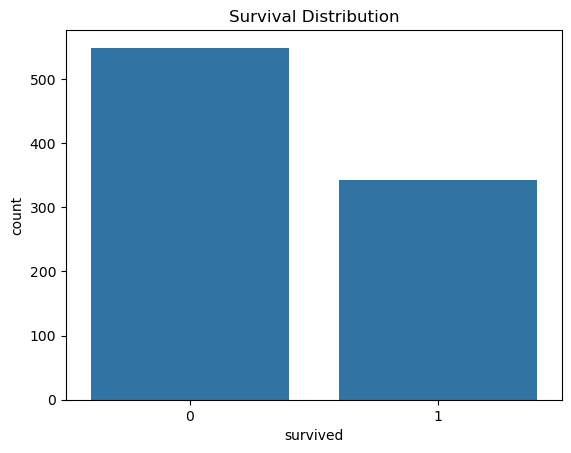

In [27]:
sns.countplot(x='survived', data=titanic)
plt.title('Survival Distribution')
plt.show()

Visualization - Age distribution with KDE (kernel density estimation)

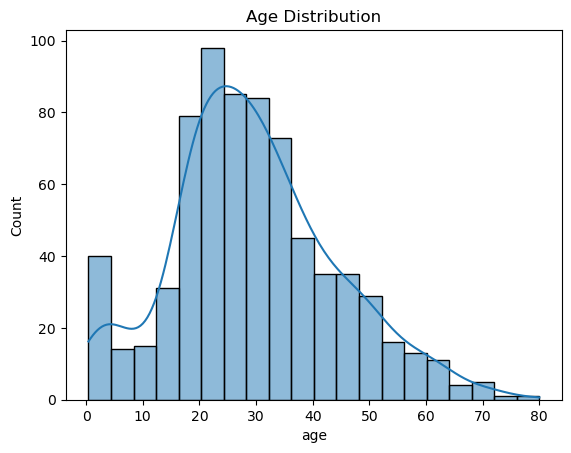

In [30]:
sns.histplot(titanic['age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

Heatmap of Correlations

We will first create a correlation matrix for numerical columns and visualize it using a heatmap

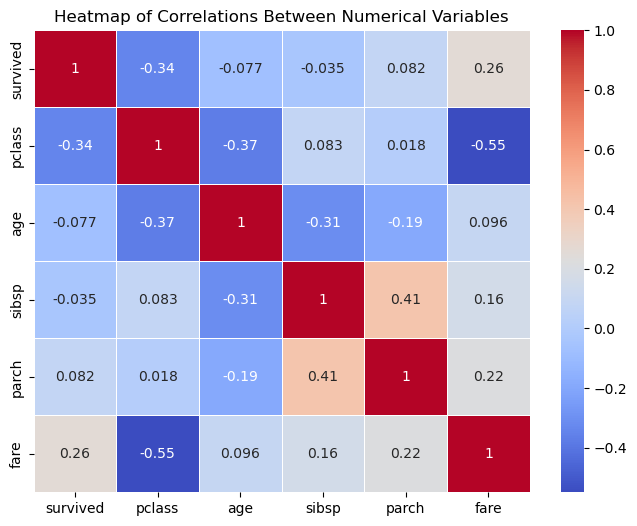

In [34]:
numeric_columns = titanic.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlations Between Numerical Variables')
plt.show()

Strip Plot (Relationship between Survival and Age)

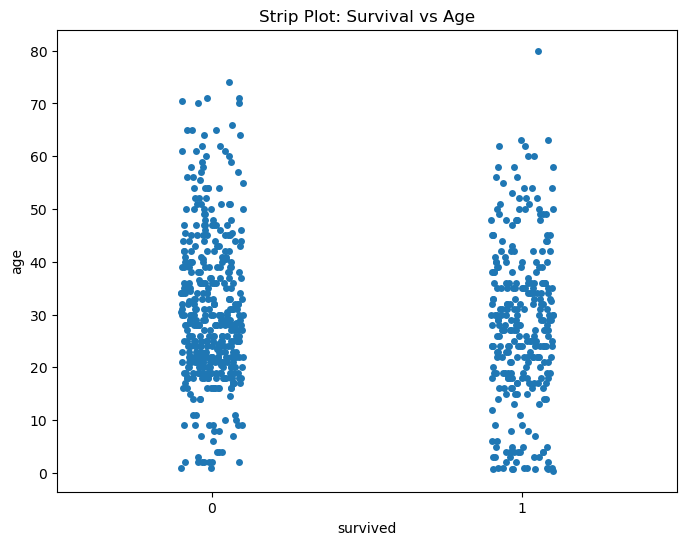

In [37]:
plt.figure(figsize=(8, 6))
sns.stripplot(x='survived', y='age', data=titanic, jitter=True)
plt.title('Strip Plot: Survival vs Age')
plt.show()

Heatmap of Survival by Class and Sex

We'll create a pivot table to aggregate data by class and sex, showing the survival rates


In [40]:
pivot_table = titanic.pivot_table(values='survived', index='class', columns='sex', aggfunc='mean')



C:\Users\Heisk\AppData\Local\Temp\ipykernel_23360\3834191050.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = titanic.pivot_table(values='survived', index='class', columns='sex', aggfunc='mean')


Plotting the heatmap for survival rates by class and sex


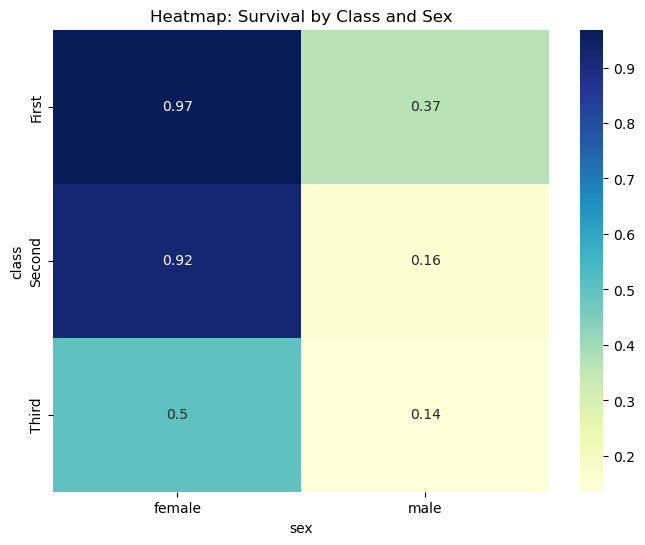

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')
plt.title('Heatmap: Survival by Class and Sex')
plt.show()

# Tutorial 2: Data Preprocessing

### Before training a machine learning model, we need to clean and prepare the data. This includes handling missing values, converting categorical variables to numerical values (so that the model can work with them), and dropping any unnecessary columns that won’t be useful in the model.

Handling missing values

Filling missing values in 'age' with the median age

In [49]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

In [60]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Handling categorical variables by converting them to numerical

Convert 'sex', 'embarked', and 'class' columns to numerical format using one-hot encoding


In [90]:
titanic_encoded = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who'], drop_first=True)

In [92]:
titanic_encoded.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,deck,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,0,3,22.0,1,0,7.2500,True,NaN,Southampton,no,False,True,False,True,False,True,True,False
1,1,1,38.0,1,0,71.2833,False,C,Cherbourg,yes,False,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,NaN,Southampton,yes,True,False,False,True,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,C,Southampton,yes,False,False,False,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,NaN,Southampton,no,True,True,False,True,False,True,True,False


Dropping unnecessary columns

Columns like 'deck', 'alive', and 'embark_town' are not needed for modeling, so we drop them

In [95]:
titanic_encoded.drop(['deck', 'alive', 'embark_town'], axis=1, inplace=True)

In [97]:
titanic_encoded.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,0,3,22.0,1,0,7.2500,True,False,True,False,True,False,True,True,False
1,1,1,38.0,1,0,71.2833,False,False,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,True,False,False,True,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,False,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,True,True,False,True,False,True,True,False


# Tutorial 3: Splitting the Dataset & Training Models

### Once the dataset is preprocessed, we need to split it into two parts: a training set (to train the model) and a test set (to evaluate the model). In this tutorial, we will train four different machine learning models: Logistic Regression, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM).

Import necessary libraries for machine learning models from scikit-learn

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

Split the data into features (X) and target (y)


In [105]:
X = titanic_encoded.drop('survived', axis=1)
y = titanic_encoded['survived']

Split the dataset into training and testing sets (70% training, 30% testing)


In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Train Logistic Regression


In [111]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Train Random Forest Classifier


In [116]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

Train K-Nearest Neighbors



In [119]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

Train Support Vector Machine


In [122]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

SVC(probability=True)

# Tutorial 4: Cross-Validation and Model Evaluation

### After training the models, we need to evaluate their performance using metrics like precision, recall, and F1-score. Cross-validation helps ensure that our model performs consistently across different subsets of the data. In this tutorial, we will calculate precision, recall, F1-score, and perform cross-validation.

In [137]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

from sklearn.model_selection import cross_val_score


#### Predict on the test data for each model

Logistic Regression

In [139]:

y_pred_logreg = logreg.predict(X_test)
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       157
           1       0.81      0.74      0.77       111

    accuracy                           0.82       268
   macro avg       0.82      0.81      0.81       268
weighted avg       0.82      0.82      0.82       268



Random Forest

In [143]:
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82       157
           1       0.76      0.69      0.73       111

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



K-Nearest Neighbors

In [146]:

y_pred_knn = knn.predict(X_test)
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.83      0.78       157
           1       0.71      0.57      0.63       111

    accuracy                           0.72       268
   macro avg       0.72      0.70      0.70       268
weighted avg       0.72      0.72      0.72       268



Support Vector Machine

In [149]:
y_pred_svm = svm.predict(X_test)
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.94      0.76       157
           1       0.74      0.26      0.39       111

    accuracy                           0.66       268
   macro avg       0.69      0.60      0.57       268
weighted avg       0.68      0.66      0.61       268



#### Perform cross-validation for each model

Logistic Regression Cross-validation


In [157]:
logreg_cv = cross_val_score(logreg, X, y, cv=5)
print("Logistic Regression Cross-Validation Scores:", logreg_cv)


Logistic Regression Cross-Validation Scores: [0.82122905 0.79775281 0.80898876 0.80337079 0.85955056]


Random Forest Cross-validation

In [162]:

rf_cv = cross_val_score(rf, X, y, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv)


Random Forest Cross-Validation Scores: [0.79888268 0.79775281 0.84269663 0.7752809  0.81460674]


KNN Cross-validation

In [166]:
knn_cv = cross_val_score(knn, X, y, cv=5)
print("KNN Cross-Validation Scores:", knn_cv)

KNN Cross-Validation Scores: [0.69832402 0.70224719 0.75842697 0.75280899 0.74719101]


SVM Cross-validation

In [169]:
svm_cv = cross_val_score(svm, X, y, cv=5)
print("SVM Cross-Validation Scores:", svm_cv)

SVM Cross-Validation Scores: [0.59776536 0.71348315 0.69101124 0.68539326 0.69101124]
